# 03 — Day + Night LST and Multi-Year Time Series

**Author:** Sharon Christa  
**Date:** April 2026  
**Purpose:** Extend the baseline LST analysis (notebook 02) in two ways:

1. **Add nighttime LST** (`LST_Night_1km`). The literature (Siswanto et al. 2023; recent Asian UHI studies) consistently finds that **nighttime UHI signals are stronger and trend upward more sharply** than daytime. Singapore's dense built environment in particular should show a strong nocturnal heat retention signal.

2. **Add multiple timestamps**: 2005, 2010, 2015, 2020, 2025. Two snapshots (2020 vs 2025) give us a *difference*, not a *trend*. With five timestamps across 20 years we can fit a linear trend and make defensible claims about warming rate.

### What's produced in this notebook

- Day + night LST composites for both cities, years 2005, 2010, 2015, 2020, 2025
- Mean LST time series (line chart) for both cities, day and night
- Annual warming rate (°C/decade) via linear regression on the 5 points
- Day-night temperature difference (diurnal range) — a UHI sensitivity metric
- Exported CSV of annual statistics for downstream use in notebooks 04, 05, 06

### Method note (for reproducibility)

Dataset: **MODIS/061/MOD11A2** — 8-day composites, 1 km resolution.  
Aggregation: annual median of 8-day LST composites (fills cloud gaps).  
Scaling: raw × 0.02 − 273.15 to convert to °C.  
AOI: GAUL 2024 boundaries (same as notebooks 01 and 02).

## 1. Setup

In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

In [3]:
try:
    import sys
    sys.path.append('..')
    from src.gee_helpers import init_ee
    init_ee()
except Exception:
    # Fallback inline init (update project ID if running standalone)
    try:
        ee.Initialize(project='black-octagon-291810')
        print('EE initialised with project: black-octagon-291810')
    except Exception as e:
        ee.Authenticate()
        ee.Initialize(project='black-octagon-291810')
        print('EE initialised after authentication')

Earth Engine initialized with project: black-octagon-291810


## 2. Areas of Interest

Same GAUL boundaries as notebooks 01 and 02 so results are comparable.

In [4]:
# Dar es Salaam (Tanzania) - GAUL Level 1 region
aoi_dar = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
           .filter(ee.Filter.eq("gaul1_name", "Dar Es Salaam")))
dar_geom = aoi_dar.geometry()

# Singapore - GAUL Level 0 country
aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

# Quick sanity check - area in sq km
def area_km2(geom):
    return geom.area(maxError=1).divide(1e6).getInfo()

print(f"Dar es Salaam AOI: {area_km2(dar_geom):.1f} sq km")
print(f"Singapore AOI:     {area_km2(sgp_geom):.1f} sq km")

Dar es Salaam AOI: 1622.9 sq km
Singapore AOI:     596.7 sq km


## 3. LST pipeline — day and night, multiple years

Two helper functions:
- `prepare_lst(image, band)`: applies the MODIS scale factor (0.02) and converts Kelvin → Celsius for a given band.
- `get_annual_lst(geom, year, band)`: builds an annual median composite for the specified year and band.

We then loop over `YEARS = [2005, 2010, 2015, 2020, 2025]` and both bands to build a dictionary of composites we can query.

In [5]:
YEARS = [2005, 2010, 2015, 2020, 2025]
BANDS = {'day': 'LST_Day_1km', 'night': 'LST_Night_1km'}


def prepare_lst(image, band):
    """Scale MODIS LST to Celsius. Returns single-band image named <band>."""
    return (image.select(band)
                 .multiply(0.02)
                 .subtract(273.15)
                 .copyProperties(image, ['system:time_start']))


def get_annual_lst(geom, year, band):
    """Annual median MODIS LST composite for a given band (day/night)."""
    start = f'{year}-01-01'
    end   = f'{year}-12-31'
    col = (ee.ImageCollection("MODIS/061/MOD11A2")
             .filterBounds(geom)
             .filterDate(start, end)
             .map(lambda img: prepare_lst(img, band)))
    return col.median().clip(geom).rename(band)


# Build composites: composites[city][year][tod] = EE image
composites = {'dar': {}, 'sgp': {}}
for year in YEARS:
    composites['dar'][year] = {
        tod: get_annual_lst(dar_geom, year, band) for tod, band in BANDS.items()
    }
    composites['sgp'][year] = {
        tod: get_annual_lst(sgp_geom, year, band) for tod, band in BANDS.items()
    }

print(f"Built {len(YEARS)} annual composites × 2 cities × 2 time-of-day = {len(YEARS)*4} images")

Built 5 annual composites × 2 cities × 2 time-of-day = 20 images


## 4. Extract area-mean statistics

For each city × year × time-of-day we extract:
- **mean LST** (°C) across the AOI
- **standard deviation** — a proxy for thermal diversity within the city
- **min** and **max** — for thermal spread

`reduceRegion` runs server-side; `getInfo()` pulls the scalar result back. This is the only time-consuming step in the notebook (one API call per combination × 4 reducers = 100 calls). Takes ~30-60s total.

In [6]:
def extract_stats(image, geom, band_name):
    """Mean, std, min, max for one image over one geometry."""
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean()
                  .combine(ee.Reducer.stdDev(), sharedInputs=True)
                  .combine(ee.Reducer.minMax(),  sharedInputs=True),
        geometry=geom,
        scale=1000,
        maxPixels=1e9
    )
    info = stats.getInfo()
    return {
        'mean': info.get(f'{band_name}_mean'),
        'std':  info.get(f'{band_name}_stdDev'),
        'min':  info.get(f'{band_name}_min'),
        'max':  info.get(f'{band_name}_max'),
    }


geoms = {'dar': dar_geom, 'sgp': sgp_geom}
rows = []
for city, geom in geoms.items():
    for year in YEARS:
        for tod, band in BANDS.items():
            s = extract_stats(composites[city][year][tod], geom, band)
            rows.append({
                'city': city,
                'year': year,
                'tod':  tod,
                **s,
            })
            print(f"  {city:4s} {year} {tod:5s}  mean={s['mean']:.2f}  "
                  f"std={s['std']:.2f}  min={s['min']:.2f}  max={s['max']:.2f}")

df = pd.DataFrame(rows)
df['spread'] = df['max'] - df['min']
df.head(10)

  dar  2005 day    mean=32.70  std=1.57  min=27.67  max=37.61
  dar  2005 night  mean=21.91  std=0.75  min=19.59  max=24.11
  dar  2010 day    mean=33.16  std=1.60  min=28.33  max=38.36
  dar  2010 night  mean=22.80  std=0.54  min=21.01  max=24.56
  dar  2015 day    mean=33.33  std=1.75  min=27.63  max=38.99
  dar  2015 night  mean=22.68  std=0.56  min=20.90  max=24.17
  dar  2020 day    mean=32.20  std=1.64  min=27.29  max=39.78
  dar  2020 night  mean=22.76  std=0.59  min=20.90  max=24.31
  dar  2025 day    mean=29.80  std=1.32  min=26.09  max=34.37
  dar  2025 night  mean=23.61  std=0.55  min=21.80  max=25.03
  sgp  2005 day    mean=32.55  std=2.38  min=27.43  max=37.81
  sgp  2005 night  mean=24.80  std=0.75  min=22.93  max=26.71
  sgp  2010 day    mean=33.18  std=2.84  min=27.14  max=39.65
  sgp  2010 night  mean=25.00  std=0.71  min=23.18  max=26.99
  sgp  2015 day    mean=33.19  std=2.69  min=26.61  max=38.78
  sgp  2015 night  mean=25.00  std=0.73  min=23.21  max=27.49
  sgp  2

,city,year,tod,mean,std,min,max,spread
0,dar,2005,day,32.696306,1.565428,27.67,37.61,9.94
1,dar,2005,night,21.906461,0.752807,19.59,24.11,4.52
2,dar,2010,day,33.164175,1.599694,28.33,38.36,10.03
3,dar,2010,night,22.803200,0.537386,21.01,24.56,3.55
4,dar,2015,day,33.333814,1.750605,27.63,38.99,11.36
5,dar,2015,night,22.677155,0.559185,20.90,24.17,3.27
6,dar,2020,day,32.195795,1.640172,27.29,39.78,12.49
7,dar,2020,night,22.755727,0.594209,20.90,24.31,3.41
8,dar,2025,day,29.797722,1.324817,26.09,34.37,8.28
9,dar,2025,night,23.607613,0.550395,21.80,25.03,3.23


## 5. Fit a linear trend — annual warming rate

For each city × time-of-day, fit `mean_LST = a + b * year` and report:
- slope `b` in **°C/decade** (multiply by 10)
- intercept
- R² — how linear the trend actually is

For reference: Siswanto et al. (2016) report Jakarta's minimum temperature increasing at **0.3-0.75 °C/decade** over 1980-2012. A 20-year (2005-2025) trend from this analysis should sit in a similar ballpark if the UHI signal is real.

In [7]:
from scipy.stats import linregress

trend_rows = []
for city in ['dar', 'sgp']:
    for tod in ['day', 'night']:
        sub = df[(df.city == city) & (df.tod == tod)].sort_values('year')
        reg = linregress(sub['year'], sub['mean'])
        trend_rows.append({
            'city': city,
            'tod':  tod,
            'slope_C_per_decade': reg.slope * 10,
            'intercept': reg.intercept,
            'r_squared': reg.rvalue ** 2,
            'p_value':   reg.pvalue,
        })

trend_df = pd.DataFrame(trend_rows)
print("Linear warming trends, 2005-2025 (MODIS Terra, annual median):")
print(trend_df.to_string(index=False))

Linear warming trends, 2005-2025 (MODIS Terra, annual median):
city   tod  slope_C_per_decade   intercept  r_squared  p_value
 dar   day           -1.353110  304.889154   0.556480 0.147694
 dar night            0.670966 -112.449635   0.773411 0.049333
 sgp   day           -0.757447  185.221175   0.226427 0.417849
 sgp night            0.607536  -97.164362   0.788754 0.044162


## 6. Time series plots

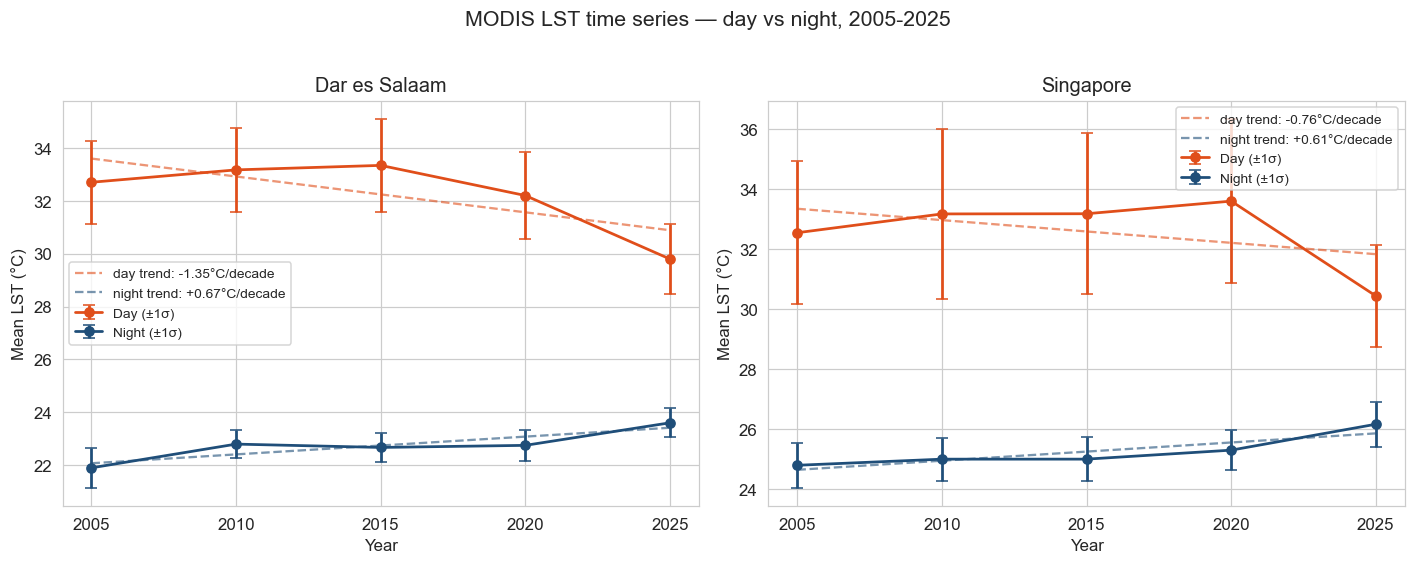

Saved: D:\uhi-dar-singapore\outputs\figures\03_lst_timeseries.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
city_labels = {'dar': 'Dar es Salaam', 'sgp': 'Singapore'}
colors = {'day': '#E04E1A', 'night': '#1F4E79'}

for ax, city in zip(axes, ['dar', 'sgp']):
    for tod in ['day', 'night']:
        sub = df[(df.city == city) & (df.tod == tod)].sort_values('year')
        ax.errorbar(sub['year'], sub['mean'], yerr=sub['std'],
                    marker='o', capsize=4, lw=1.8, color=colors[tod],
                    label=f'{tod.capitalize()} (±1σ)')
        # Linear trend line
        reg = linregress(sub['year'], sub['mean'])
        x = np.array(sub['year'])
        ax.plot(x, reg.intercept + reg.slope * x, ls='--', color=colors[tod], alpha=0.6,
                label=f'{tod} trend: {reg.slope*10:+.2f}°C/decade')
    ax.set_title(city_labels[city], fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean LST (°C)')
    ax.legend(loc='best', fontsize=9)
    ax.set_xticks(YEARS)

plt.suptitle('MODIS LST time series — day vs night, 2005-2025', y=1.02, fontsize=14)
plt.tight_layout()

# Save for the poster
out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / '03_lst_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {(out_dir / '03_lst_timeseries.png').resolve()}")

## 7. Diurnal range (day − night)

The day-night difference is a UHI-relevant signal in its own right. Cities with high heat-storage mass (concrete, asphalt) release heat slowly at night, so they tend to have a **smaller** diurnal range than their rural surroundings. A *shrinking* diurnal range over time is another UHI fingerprint.

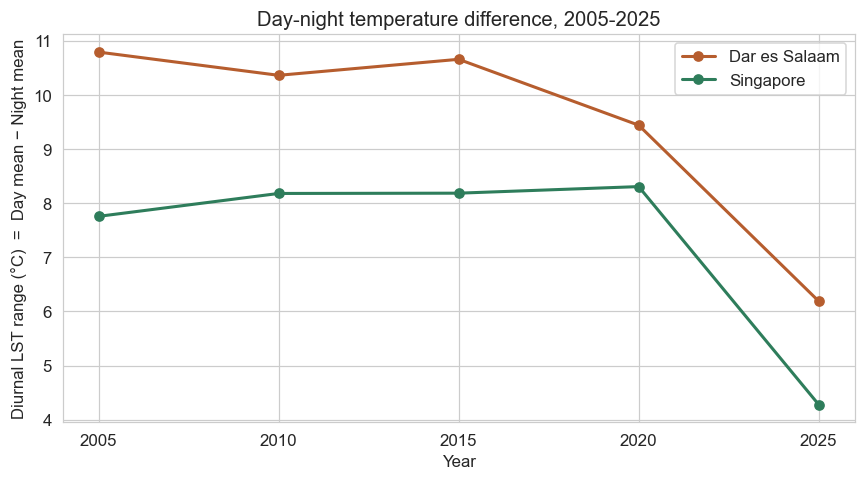


Diurnal range table:
city  year       day     night  diurnal_range
 dar  2005 32.696306 21.906461      10.789845
 dar  2010 33.164175 22.803200      10.360975
 dar  2015 33.333814 22.677155      10.656659
 dar  2020 32.195795 22.755727       9.440068
 dar  2025 29.797722 23.607613       6.190109
 sgp  2005 32.554416 24.797785       7.756631
 sgp  2010 33.181070 25.001770       8.179300
 sgp  2015 33.187028 25.002522       8.184506
 sgp  2020 33.608073 25.302108       8.305965
 sgp  2025 30.447297 26.166456       4.280841


In [9]:
# Pivot so day and night become columns, then compute difference
pivot = df.pivot_table(index=['city','year'], columns='tod', values='mean').reset_index()
pivot['diurnal_range'] = pivot['day'] - pivot['night']

fig, ax = plt.subplots(figsize=(8, 4.5))
for city, color in zip(['dar', 'sgp'], ['#B65D2E', '#2E7D5B']):
    sub = pivot[pivot.city == city].sort_values('year')
    ax.plot(sub['year'], sub['diurnal_range'], marker='o', lw=2, color=color,
            label=city_labels[city])

ax.set_xlabel('Year')
ax.set_ylabel('Diurnal LST range (°C)  =  Day mean − Night mean')
ax.set_title('Day-night temperature difference, 2005-2025')
ax.set_xticks(YEARS)
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / '03_diurnal_range.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nDiurnal range table:")
print(pivot[['city','year','day','night','diurnal_range']].to_string(index=False))

## 8. Spatial map — day vs night LST, 2025

Interactive `geemap` view so you can toggle layers and see *where* the hottest pixels are. Day layers will dominate over built-up; night layers will often reveal heat-retention patterns concentrated along arterial roads and dense cores.

In [10]:
Map = geemap.Map()

lst_vis_day   = {'min': 22, 'max': 42, 'palette': ['#2C7BB6','#ABD9E9','#FFFFBF','#FDAE61','#D7191C']}
lst_vis_night = {'min': 18, 'max': 30, 'palette': ['#2C7BB6','#ABD9E9','#FFFFBF','#FDAE61','#D7191C']}

for city in ['dar', 'sgp']:
    name = city_labels[city]
    Map.addLayer(composites[city][2025]['day'],   lst_vis_day,
                 f'{name} LST Day 2025', False)
    Map.addLayer(composites[city][2025]['night'], lst_vis_night,
                 f'{name} LST Night 2025', False)

# Show Dar day and night by default
Map.layers[0].visible = True  # Dar day
Map.layers[1].visible = True  # Dar night

Map.centerObject(dar_geom, 10)
Map

Map(center=[-6.885315881886441, 39.261678578380874], controls=(WidgetControl(options=['position', 'transparent…

## 9. Export results for downstream notebooks

Saves two CSVs to `outputs/tables/`:
- `03_lst_stats.csv` — raw per-city-year-tod statistics
- `03_lst_trends.csv` — fitted warming trends
- `03_diurnal_range.csv` — diurnal summary

Notebooks 04, 05, 06 read these instead of recomputing.

In [11]:
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

df.to_csv(out_tables / '03_lst_stats.csv', index=False)
trend_df.to_csv(out_tables / '03_lst_trends.csv', index=False)
pivot.to_csv(out_tables / '03_diurnal_range.csv', index=False)

print("Saved:")
for p in out_tables.glob('03_*.csv'):
    print(f"  {p.resolve()}")

Saved:
  D:\uhi-dar-singapore\outputs\tables\03_diurnal_range.csv
  D:\uhi-dar-singapore\outputs\tables\03_lst_stats.csv
  D:\uhi-dar-singapore\outputs\tables\03_lst_trends.csv
